In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import torch
print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

2.14.0+cu132
True
NVIDIA GeForce RTX 5060 Laptop GPU


In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
from torch.utils.data import Dataset

In [ ]:
import kagglehub
path = kagglehub.competition_download('filament-segmentation-2026')

In [3]:
import json
from collections import defaultdict
from pathlib import Path
import numpy as np
from PIL import Image
import os

PROJECT_ROOT = Path.cwd()
ROOT_FOLDER_PATH = PROJECT_ROOT/ "MAGFiLO_1.0_Kaggle_2026"
JSON_FILE_PATH = ROOT_FOLDER_PATH / "train" / "MAGFiLO_1.0_Annotations_kaggle2026_train.json"
IMAGE_FOLDER_PATH = ROOT_FOLDER_PATH / "train" / "train_images"

coco_data = json.loads(JSON_FILE_PATH.read_text())
id_to_image ={im['id']:im for im in coco_data['images']}

In [4]:
anns_by_image_id = defaultdict(list)
for ann in coco_data['annotations']:
    anns_by_image_id[ann['image_id']].append(ann)

In [5]:
len(anns_by_image_id), len(id_to_image)

(1154, 1154)

In [6]:
file_to_image_ids =defaultdict(list)
for im in coco_data['images']:
    file_to_image_ids[im['file_name']].append(im['id'])

In [7]:
len(coco_data['images']), len(file_to_image_ids), len(coco_data['annotations']), len(coco_data['categories'])

(1154, 707, 8199, 4)

In [8]:
from skimage.draw import polygon as draw_polygon

In [9]:
height = width = 2048
def polygon_to_mask(segmentation, height, width):
    mask = np.zeros((height, width), dtype = np.uint8)
    for poly in segmentation:
        xy = np.asarray(poly, dtype = np.float32).reshape(-1,2)
        rows, cols = draw_polygon(xy[:,1], xy[:, 0], shape = (height, width))
        mask[rows, cols] = 1
    return mask

def instance_mask(annotations, height = height, width = width):
    return np.stack([polygon_to_mask(a['segmentation'], height, width) for a in annotations], axis = 0) if annotations else np.zeros((0, height, width), dtype = np.uint8)

def semantic_mask(annotations, height = height, width = width):
    m = np.zeros((height, width), dtype = np.uint8)
    for ann in annotations:
        m |= polygon_to_mask(ann['segmentation'], height, width)
    return m

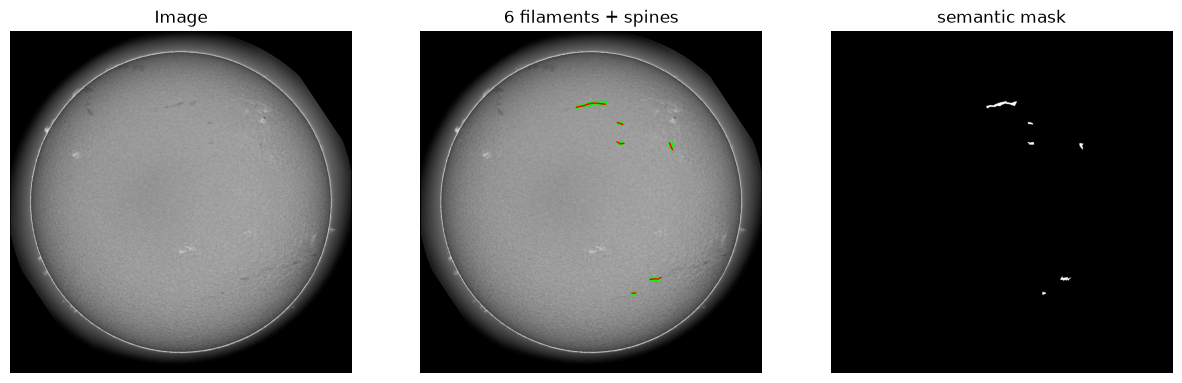

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon

def show_annotations(file_name, annotator_index = 0):
    image_id = file_to_image_ids[file_name][annotator_index]
    metadata = id_to_image[image_id]
    anns = anns_by_image_id[image_id]
    img = np.array(Image.open(IMAGE_FOLDER_PATH / file_name))

    fig,axes = plt.subplots(1,3, figsize = (15,5))
    axes[0].imshow(img, cmap  ="gray")
    axes[0].set_title("Image")

    axes[1].imshow(img, cmap = "gray")
    for a in anns:
        xy = np.array(a['segmentation'][0]).reshape(-1,2)
        axes[1].add_patch(Polygon(xy, fill = False, edgecolor = "lime", lw = 1))
        spine = np.array(a['spine']).reshape(-1, 2)
        axes[1].plot(spine[:, 0], spine[:, 1], "r-", lw = 1)
    axes[1].set_title(f"{len(anns)} filaments + spines")

    axes[2].imshow(semantic_mask(anns), cmap = 'gray')
    axes[2].set_title('semantic mask')
    for ax in axes:
        ax.axis('off')
    plt.show()

show_annotations("20110109104734Ch.jpeg", 0)

In [11]:
n_annotators = [len(v) for v in file_to_image_ids.values()]
n_filaments = [len(anns_by_image_id[i]) for i in id_to_image]
areas=[a['area'] for a in coco_data['annotations']]
print('min', min(n_annotators), 'max', max(n_annotators), 'mean', np.mean(n_annotators))
print('min', min(n_filaments), 'max', max(n_filaments), 'mean', np.mean(n_filaments))
print(np.percentile(areas, [1,50,99]))

min 1 max 3 mean 1.6322489391796322
min 1 max 26 mean 7.104852686308492
[  208.98  1228.   13703.44]


# Image Processsing

In [12]:
from skimage.exposure import equalize_adapthist
from skimage.measure import label, regionprops
from skimage.morphology import black_tophat, disk, opening, remove_small_objects
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

In [13]:
CACHE = PROJECT_ROOT / "cache_preprocessed"
# CACHE.mkdir(parents=True, exist_ok=True)

In [14]:
def load_gray(path):
    img = np.array(Image.open(path).convert("L"), dtype = np.float32)
    return img

In [15]:
def disk_mask(gray):
    g = gray/(gray.max() + 1e-6)
    binary = g > np.percentile(g[g>0], 40)
    lab = label(binary)
    regions = regionprops(lab)
    if not regions:
        yy,xx = np.ogrid[:gray.shape[0], :gray.shape[1]]
        cy, cx = gray.shape[0] /2.0
        return ((yy-cy) ** 2 + (xx-cx) **2) <= 980.0**2
    
    r = max(regions, key = lambda x: x.area)
    cy , cx = r.centroid
    radius = 0.98 *(max(r.axis_major_length, 1.0) / 2.0)
    yy,xx = np.ogrid[:gray.shape[0], :gray.shape[1]]
    return ((yy-cy)**2+(xx-cx)**2) <= radius**2

In [16]:
def limb_darkening_correction(gray, mask):
    yy, xx = np.indices(gray.shape)
    coords = np.argwhere(mask)
    cy, cx = coords.mean(axis = 0)
    r = np.sqrt((yy - cy) ** 2 + (xx - cx) ** 2)
    r_sun = r[mask].max()
    mu = np.sqrt(np.clip(1.0 - (r / (r_sun + 1e-6)) ** 2, 0.0, 1.0))

    y = gray[mask]
    X = np.column_stack([np.ones(y.size), mu[mask], mu[mask]**2])
    coef, *_ = np.linalg.lstsq(X, y, rcond =None)
    model = coef[0] + coef[1] *mu + coef[2] *mu**2
    corrected = np.zeros_like(gray, dtype =np.float32)
    corrected[mask] = gray[mask] / (model[mask] + 1e-6)
    return corrected

In [17]:
def normalize_disk(img, mask):
    pix = img[mask]
    med = np.median(pix)
    mad = np.median(np.abs(pix - med))+1e-6
    out = (img - med)/ (1.4826 * mad)
    out = np.clip(out, -6.0, 6.0)
    out = (out - out.min()) / (out.max() - out.min() + 1e-6)
    out[~mask] = 0.0
    return out.astype(np.float32)

def clache_disk(img01, mask, clip = 0.01):
    enh = equalize_adapthist(img01, clip_limit = clip)
    enh[~mask] = 0.0
    return enh.astype(np.float32)

In [18]:
def blackhat_disk(img01, mask, radius = 15):
    bh = black_tophat(img01, disk(radius))
    bh[~mask] = 0.0
    if bh.max() > 0:
        bh = bh/bh.max()
    return bh.astype(np.float32)

In [19]:
def preprocess(path):
    gray = load_gray(path)
    mask = disk_mask(gray)
    corr = limb_darkening_correction(gray, mask)
    norm = normalize_disk(corr, mask)
    enh = clache_disk(norm, mask)
    # bh = blackhat_disk(norm, mask) #not using blackhat as it is not distinguishing noise properly
    x = np.stack([norm, enh, enh], axis = -1)
    return x, mask

def load_preprocessed(file_name, image_dir = IMAGE_FOLDER_PATH):
    npy = CACHE/f"{file_name}.npy"
    if npy.exists():
        return np.load(npy)
    x, _ = preprocess(image_dir/file_name)
    np.save(npy, x)
    return x

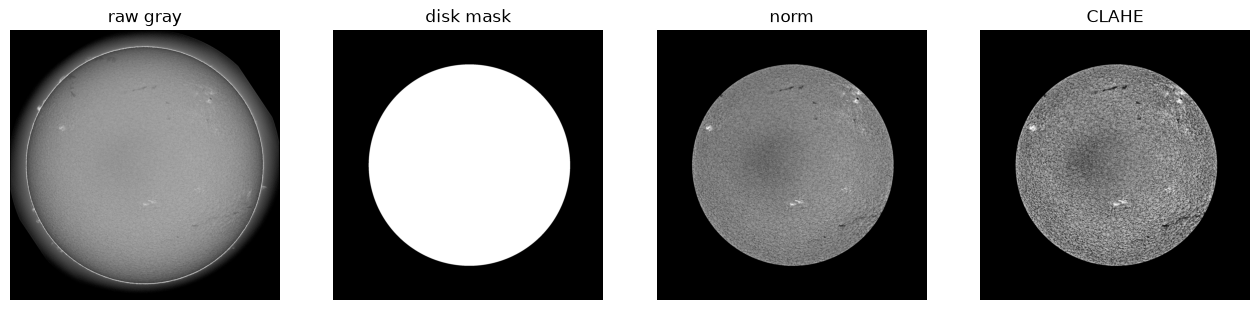

shapes (2048, 2048) (2048, 2048, 3) channels equal 1==2 True


In [20]:
import matplotlib.pyplot as plt

file_name = "20110109104734Ch.jpeg"
gray = load_gray(IMAGE_FOLDER_PATH / file_name)
x, dmask = preprocess(IMAGE_FOLDER_PATH / file_name)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
titles = ["raw gray", "disk mask", "norm", "CLAHE"]
ims = [gray, dmask, x[..., 0], x[..., 1]]
for ax, im, t in zip(axes, ims, titles):
    ax.imshow(im, cmap="gray")
    ax.set_title(t)
    ax.axis("off")
plt.show()

print("shapes", gray.shape, x.shape, "channels equal 1==2", np.allclose(x[..., 1], x[..., 2]))

In [21]:
from sklearn.model_selection import train_test_split
files = np.array(sorted(file_to_image_ids.keys()))
train_files, val_files = train_test_split(files, test_size = 0.15, random_state = 42)

def samples_from(file_list):
    out = []
    for fn in file_list:
        for image_id in file_to_image_ids[fn]:
            out.append((fn, image_id))
    return out

train_samples = samples_from(train_files)
val_samples = samples_from(val_files)
print(len(train_files), len(val_files), len(train_samples), len(val_samples))

600 107 976 178


In [22]:
def classical_instances(file_name, min_area = 80):
    x, dmask = preprocess(IMAGE_FOLDER_PATH/file_name)
    clahe = x[..., 1]
    feat = (1.0 - clahe)*dmask
    t = threshold_otsu(feat[dmask]) if dmask.any () else 0.5
    bw = (feat > t) & dmask
    bw = opening(bw, disk(2))
    bw =remove_small_objects(bw, min_size = min_area)
    lab = label(bw)
    return [lab == i for i in range(1, lab.max() - 1)]

(np.float64(-0.5), np.float64(2047.5), np.float64(2047.5), np.float64(-0.5))

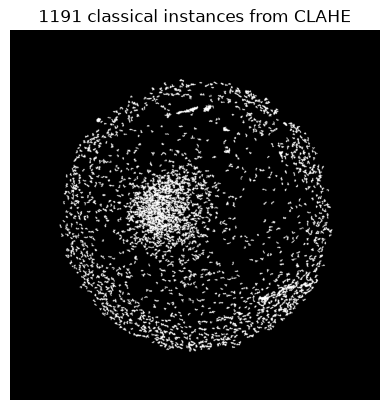

In [25]:
inst = classical_instances(file_name)
plt.imshow(np.any(inst, axis=0) if inst else np.zeros((height, width)), cmap="gray")
plt.title(f"{len(inst)} classical instances from CLAHE")
plt.axis("off")

In [1]:
from functools import lru_cache
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import Dataset
from tqdm.auto import tqdm

TILE = 512
STRIDE = 384
MASK_CACHE = PROJECT_ROOT / "cache_preprocessed" / "masks"
MASK_CACHE.mkdir(parents=True, exist_ok=True)


def iter_tiles(height=height, width=width, tile=TILE, stride=STRIDE):
    ys = list(range(0, height - tile + 1, stride))
    xs = list(range(0, width - tile + 1, stride))
    if ys[-1] != height - tile:
        ys.append(height - tile)
    if xs[-1] != width - tile:
        xs.append(width - tile)
    for y in ys:
        for x in xs:
            yield y, x


def load_semantic_mask(image_id):
    path = MASK_CACHE / f"{image_id}.npy"
    if path.exists():
        return np.load(path, mmap_mode="r")
    m = semantic_mask(anns_by_image_id[image_id])
    np.save(path, m)
    return m


@lru_cache(maxsize=64)
def load_image_cached(file_name):
    return load_preprocessed(file_name)


class FilamentTiles(Dataset):
    def __init__(self, samples, augment=False, keep_empty_prob=0.15):
        self.augment = augment
        self.keep_empty_prob = keep_empty_prob
        self.index = []
        self.fg_indices = []

        for fn, image_id in tqdm(samples, desc="index tiles"):
            sem = np.asarray(load_semantic_mask(image_id))
            for y, x in iter_tiles():
                has_fg = bool(sem[y:y + TILE, x:x + TILE].any())
                self.index.append((fn, image_id, y, x, has_fg))
                if has_fg:
                    self.fg_indices.append(len(self.index) - 1)

        if not self.fg_indices:
            raise ValueError("No filament tiles found. Check masks / split.")

    def __len__(self):
        return len(self.index)

    def _crop(self, fn, image_id, y, x):
        # .copy() so flip/rot90 cannot edit the cache
        img = np.asarray(load_image_cached(fn)[y:y + TILE, x:x + TILE]).copy()
        mask = np.asarray(load_semantic_mask(image_id)[y:y + TILE, x:x + TILE]).copy()
        return img, mask

    def __getitem__(self, i):
        fn, image_id, y, x, has_fg = self.index[i]
        if (not has_fg) and (np.random.rand() > self.keep_empty_prob):
            j = self.fg_indices[int(np.random.randint(0, len(self.fg_indices)))]
            fn, image_id, y, x, has_fg = self.index[j]

        img, mask = self._crop(fn, image_id, y, x)

        if self.augment:
            if np.random.rand() < 0.5:
                img = img[:, ::-1]
                mask = mask[:, ::-1]
            if np.random.rand() < 0.5:
                img = img[::-1]
                mask = mask[::-1]
            k = int(np.random.randint(0, 4))
            img = np.rot90(img, k)
            mask = np.rot90(mask, k)

        img = torch.from_numpy(np.ascontiguousarray(img.transpose(2, 0, 1)))
        mask = torch.from_numpy(np.ascontiguousarray(mask[None].astype(np.float32)))
        return img.float(), mask

NameError: name 'PROJECT_ROOT' is not defined

In [ ]:
from torch.utils.data import DataLoader

loader_kw = dict(batch_size=8, pin_memory=True, num_workers=0)

print("building train dataset...")
train_ds = FilamentTiles(train_samples, augment=True)
print("train tiles", len(train_ds), "filament tiles", len(train_ds.fg_indices))

print("building val dataset...")
val_ds = FilamentTiles(val_samples, augment=False)
print("val tiles", len(val_ds))

train_loader = DataLoader(train_ds, shuffle=True, **loader_kw)
val_loader = DataLoader(val_ds, shuffle=False, **loader_kw)

building train dataset...


index tiles:   0%|          | 0/976 [00:00<?, ?it/s]

train tiles 24400 filament tiles 9862
building val dataset...


index tiles:   0%|          | 0/178 [00:00<?, ?it/s]

val tiles 4450


In [ ]:
import time
import torch.nn as nn
from tqdm.auto import tqdm
import segmentation_models_pytorch as smp

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device", device)

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
).to(device)

ckpt = PROJECT_ROOT / "unet_best.pt"
if ckpt.exists():
    model.load_state_dict(torch.load(ckpt, map_location=device))
    print("loaded", ckpt)
else:
    print("no checkpoint, training from scratch")

bce = nn.BCEWithLogitsLoss()
dice = smp.losses.DiceLoss(mode="binary")

def loss_fn(logits, y):
    return 0.5 * bce(logits, y) + 0.5 * dice(logits, y)

opt = torch.optim.Adam(model.parameters(), lr=1e-4)
best = 0.1991

for epoch in range(20):
    model.train()
    tr = 0.0
    pbar = tqdm(train_loader, desc=f"epoch {epoch} train", leave=True)
    for step, (x, y) in enumerate(pbar, start=1):
        x, y = x.to(device), y.to(device)
        opt.zero_grad()
        loss = loss_fn(model(x), y)
        loss.backward()
        opt.step()
        tr += loss.item()
        pbar.set_postfix(loss=f"{tr / step:.4f}")

    model.eval()
    va = 0.0
    with torch.no_grad():
        pbar = tqdm(val_loader, desc=f"epoch {epoch} val", leave=True)
        for step, (x, y) in enumerate(pbar, start=1):
            x, y = x.to(device), y.to(device)
            va += loss_fn(model(x), y).item()
            pbar.set_postfix(loss=f"{va / step:.4f}")

    tr /= max(len(train_loader), 1)
    va /= max(len(val_loader), 1)
    print(f"epoch {epoch}  train {tr:.4f}  val {va:.4f}")
    if va < best:
        best = va
        torch.save(model.state_dict(), ckpt)
        print("saved", ckpt)

device cuda
loaded d:\local_files\Solar Filament Segmentation Challenge\unet_best.pt


epoch 0 train:   0%|          | 0/3050 [00:00<?, ?it/s]

epoch 0 val:   0%|          | 0/557 [00:00<?, ?it/s]

epoch 0  train 0.1772  val 0.1869
saved d:\local_files\Solar Filament Segmentation Challenge\unet_best.pt


epoch 1 train:   0%|          | 0/3050 [00:00<?, ?it/s]

...

epoch 17 train:   0%|          | 0/3050 [00:00<?, ?it/s]

epoch 17 val:   0%|          | 0/557 [00:00<?, ?it/s]

epoch 17  train 0.1484  val 0.1823


epoch 18 train:   0%|          | 0/3050 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import segmentation_models_pytorch as smp
device = "cuda" if torch.cuda.is_available() else "cpu"
ckpt = PROJECT_ROOT / "unet_best.pt"

if not ckpt.exists():
    raise FileNotFoundError(ckpt)

model = smp.Unet(encoder_name =  "resnet34", encoder_weights = None, in_channels = 3, classes = 1).to(device)

model.load_state_dict(torch.load(ckpt, map_location = device))
model.eval()
print("loaded epoch-8 best model")
print("device", device, "file_mb", round(ckpt.stat().st_size /1e6, 1))

loaded epoch-8 best model
device cuda file_mb 97.9


C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


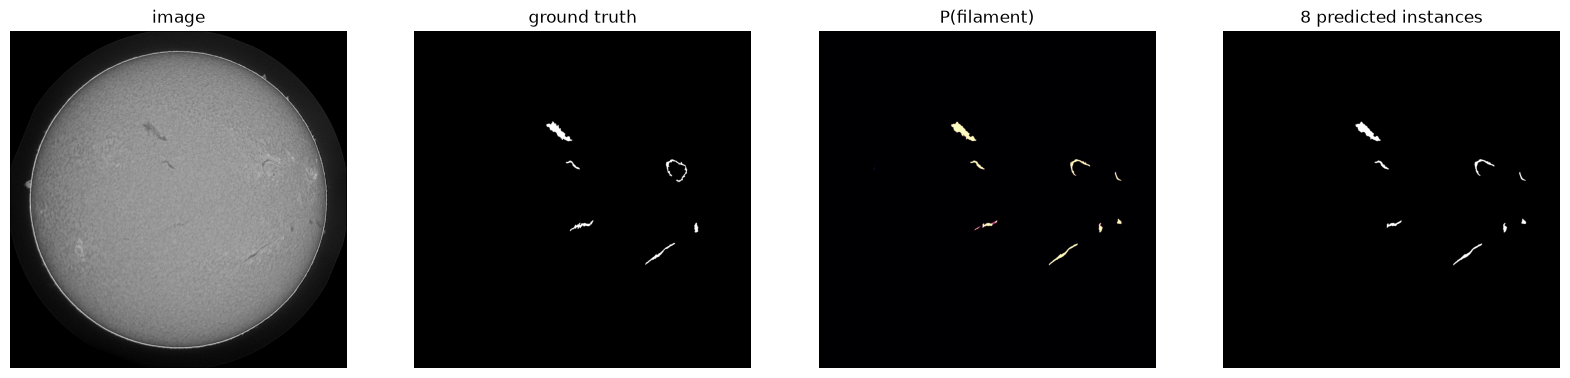

In [ ]:
from skimage.morphology import opening, remove_small_objects, disk, closing
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from skimage.measure import label
from scipy import ndimage as ndi

H = W = height

def predict_prob(file_name, model, image_dir = IMAGE_FOLDER_PATH):
    img = load_preprocessed(file_name, image_dir = image_dir)
    prob = np.zeros((H, W), dtype = np.float32)
    count = np.zeros((H, W), dtype = np.float32)
    model.eval()
    with torch.no_grad():
        for y, x in iter_tiles():
            tile = img[y:y+TILE, x:x+TILE]
            t = torch.from_numpy(np.ascontiguousarray(tile.transpose(2, 0, 1)[None])).float().to(device)
            p = torch.sigmoid(model(t))[0,0].cpu().numpy()
            prob[y:y + TILE, x:x+TILE] += p
            count[y:y+TILE, x:x+TILE] += 1
    return prob/np.clip(count, 1, None)

# def instances_from_prob(prob, dmask, min_area = 80, t = 0.45, min_distance = 15):
#     bw = (prob > t) & dmask
#     bw = opening(bw, disk(2))
#     bw = remove_small_objects(bw, min_size = min_area)
#     dist = ndi.distance_transform_edt(bw)
#     peaks = peak_local_max(dist, min_distance = min_distance, labels = bw)
#     markers = np.zeros_like(bw, dtype = np.int32)
#     for i , (r,c) in enumerate(peaks, start = 1):
#         markers[r,c] = i
#     lab = watershed(-dist, markers, mask = bw)
#     return [lab == i for i in range(1, int(lab.max()) + 1)]

def instances_from_prob(prob, dmask, t=0.45, min_area=300):
    bw = (prob > t) & dmask
    bw = closing(bw, disk(3))
    bw = remove_small_objects(bw, min_size=min_area)
    lab = label(bw)
    return [lab == i for i in range(1, int(lab.max()) + 1)]

fn = str(val_files[0])
gray = load_gray(IMAGE_FOLDER_PATH / fn)
dmask = disk_mask(gray)
prob = predict_prob(fn, model)
inst = instances_from_prob(prob, dmask)
image_id = file_to_image_ids[fn][0]
gt = semantic_mask(anns_by_image_id[image_id])
fig, ax = plt.subplots(1, 4, figsize=(20, 5))
ax[0].imshow(gray, cmap="gray")
ax[0].set_title("image")
ax[1].imshow(gt, cmap="gray")
ax[1].set_title("ground truth")
ax[2].imshow(prob, cmap="magma")
ax[2].set_title("P(filament)")
ax[3].imshow(np.any(inst, axis=0) if inst else np.zeros((H, W)), cmap="gray")
ax[3].set_title(f"{len(inst)} predicted instances")
for a in ax:
    a.axis("off")
plt.show()



In [31]:
def iou(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return float(inter / union) if union else 0.0

def panoptic_quality(gt_masks, pred_masks, iou_thr=0.5):
    if (not gt_masks) and (not pred_masks):
        return 1.0
    pairs = []
    for i, g in enumerate(gt_masks):
        for j, p in enumerate(pred_masks):
            v = iou(g, p)
            if v >= iou_thr:
                pairs.append((v, i, j))
    pairs.sort(reverse=True)
    used_g, used_p, ious = set(), set(), []
    for v, i, j in pairs:
        if i in used_g or j in used_p:
            continue
        used_g.add(i)
        used_p.add(j)
        ious.append(v)
    tp, fp, fn = len(ious), len(pred_masks) - len(ious), len(gt_masks) - len(ious)
    den = tp + 0.5 * fp + 0.5 * fn
    return float(sum(ious) / den) if den else 0.0

pqs = []
for fn in list(val_files)[:20]:
    fn = str(fn)
    gray = load_gray(IMAGE_FOLDER_PATH / fn)
    pred = instances_from_prob(predict_prob(fn, model), disk_mask(gray), t=0.45)
    image_id = file_to_image_ids[fn][0]
    gt = [m.astype(bool) for m in instance_mask(anns_by_image_id[image_id])]
    pred = [m.astype(bool) for m in pred]
    pqs.append(panoptic_quality(gt, pred))
print("mean PQ (20 val images)", float(np.mean(pqs)))

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\1111127429.py:25: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size = min_area)


mean PQ (20 val images) 0.06396164957500099


In [32]:
n_gt, n_pred = [], []
for fn in list(val_files)[:20]:
    fn = str(fn)
    gray = load_gray(IMAGE_FOLDER_PATH / fn)
    pred = instances_from_prob(predict_prob(fn, model), disk_mask(gray), t=0.45)
    image_id = file_to_image_ids[fn][0]
    gt = instance_mask(anns_by_image_id[image_id])
    n_gt.append(len(gt))
    n_pred.append(len(pred))
print("mean GT filaments", np.mean(n_gt))
print("mean predicted", np.mean(n_pred))

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\1111127429.py:25: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size = min_area)


mean GT filaments 6.4
mean predicted 27.1


In [ ]:
import numpy as np
import torch
from collections import defaultdict
from tqdm.auto import tqdm

def to_bool_list(masks):
    out = []
    for m in masks:
        m = np.asarray(m).astype(bool)
        if m.any():
            out.append(m)
    return out

def iou_dice(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    sa, sb = a.sum(), b.sum()
    iou = float(inter / union) if union else 0.0
    dice = float(2 * inter / (sa + sb)) if (sa + sb) else 1.0
    return iou, dice

def iou_matrix(gt_masks, pred_masks):
    g, p = len(gt_masks), len(pred_masks)
    M = np.zeros((g, p), dtype=np.float32)
    D = np.zeros((g, p), dtype=np.float32)
    for i, gmask in enumerate(gt_masks):
        for j, pmask in enumerate(pred_masks):
            M[i, j], D[i, j] = iou_dice(gmask, pmask)
    return M, D

def match_at_half(M):
    pairs = []
    g, p = M.shape
    for i in range(g):
        for j in range(p):
            if M[i, j] >= 0.5:
                pairs.append((float(M[i, j]), i, j))
    pairs.sort(reverse=True)
    used_g, used_p, matches = set(), set(), []
    for v, i, j in pairs:
        if i in used_g or j in used_p:
            continue
        used_g.add(i)
        used_p.add(j)
        matches.append((i, j, v))
    return matches

def panoptic_from_match(n_gt, n_pred, matches, ious):
    tp = len(matches)
    fp = n_pred - tp
    fn = n_gt - tp
    den = tp + 0.5 * fp + 0.5 * fn
    pq = (sum(ious) / den) if den else (1.0 if n_gt == n_pred == 0 else 0.0)
    return {"pq": pq, "tp": tp, "fp": fp, "fn": fn}

def split_merge(M, overlap=0.10):
    g, p = M.shape
    one_to_many = 0
    many_to_one = 0
    if p:
        for i in range(g):
            if (M[i] >= overlap).sum() >= 2:
                one_to_many += 1
    if g:
        for j in range(p):
            if (M[:, j] >= overlap).sum() >= 2:
                many_to_one += 1
    return one_to_many, many_to_one

In [ ]:
from torchmetrics.segmentation import DiceScore

dice_tm = DiceScore(num_classes=1, average="micro")

def semantic_dice_torchmetrics(gt_union, pred_union):
    t = torch.from_numpy(gt_union.astype(np.int64)[None])
    p = torch.from_numpy(pred_union.astype(np.int64)[None])
    try:
        return float(dice_tm(p, t).cpu())
    except Exception:
        inter = np.logical_and(gt_union, pred_union).sum()
        s = gt_union.sum() + pred_union.sum()
        return float(2 * inter / s) if s else 1.0

c:\Users\Vibhanshu Botke\.conda\envs\data_science\Lib\site-packages\torchmetrics\utilities\prints.py:43: UserWarning: DiceScore metric currently defaults to `average=micro`, but will change to`average=macro` in the v1.9 release. If you've explicitly set this parameter, you can ignore this warning.
  warnings.warn(*args, **kwargs)


In [ ]:
def evaluate_image(file_name, t=0.45, min_area=80, min_distance=15):
    gray = load_gray(IMAGE_FOLDER_PATH / file_name)
    pred_list = instances_from_prob(
        predict_prob(file_name, model),
        disk_mask(gray),
        t=t,
        min_area=min_area
        # min_distance=min_distance,
    )
    image_id = file_to_image_ids[file_name][0]
    gt_list = instance_mask(anns_by_image_id[image_id])

    gt_masks = to_bool_list(gt_list)
    pred_masks = to_bool_list(pred_list)

    gt_u = np.any(gt_masks, axis=0) if gt_masks else np.zeros((height, width), dtype=bool)
    pr_u = np.any(pred_masks, axis=0) if pred_masks else np.zeros((height, width), dtype=bool)

    sem_dice = semantic_dice_torchmetrics(gt_u, pr_u)
    sem_iou, _ = iou_dice(gt_u, pr_u)

    if not gt_masks and not pred_masks:
        return {
            "file": file_name, "pq": 1.0, "sem_dice": 1.0, "sem_iou": 1.0,
            "n_gt": 0, "n_pred": 0, "tp": 0, "fp": 0, "fn": 0,
            "pair_dice": [], "pair_iou": [],
            "one_to_many": 0, "many_to_one": 0,
        }

    M, D = iou_matrix(gt_masks, pred_masks) if (gt_masks and pred_masks) else (
        np.zeros((len(gt_masks), max(len(pred_masks), 1))),
        np.zeros((len(gt_masks), max(len(pred_masks), 1))),
    )
    if not pred_masks:
        M = np.zeros((len(gt_masks), 0))
        D = np.zeros((len(gt_masks), 0))
    matches = match_at_half(M) if M.size else []
    pair_iou = [m[2] for m in matches]
    pair_dice = [float(D[i, j]) for i, j, _ in matches] if D.size else []
    stats = panoptic_from_match(len(gt_masks), len(pred_masks), matches, pair_iou)
    o2m, m2o = split_merge(M, overlap=0.10) if M.size else (0, 0)

    return {
        "file": file_name,
        "pq": stats["pq"],
        "sem_dice": sem_dice,
        "sem_iou": sem_iou,
        "n_gt": len(gt_masks),
        "n_pred": len(pred_masks),
        "tp": stats["tp"],
        "fp": stats["fp"],
        "fn": stats["fn"],
        "pair_dice": pair_dice,
        "pair_iou": pair_iou,
        "one_to_many": o2m,
        "many_to_one": m2o,
    }


rows = []
for fn in tqdm(list(map(str, val_files)), desc="eval val"):
    rows.append(evaluate_image(fn, t=0.45))

pq = np.array([r["pq"] for r in rows])
sem_dice = np.array([r["sem_dice"] for r in rows])
sem_iou = np.array([r["sem_iou"] for r in rows])
pair_dice = np.array([d for r in rows for d in r["pair_dice"]])
pair_iou = np.array([d for r in rows for d in r["pair_iou"]])

print("images", len(rows))
print("mean PQ", pq.mean())
print("mean semantic Dice", sem_dice.mean())
print("mean semantic IoU ", sem_iou.mean())
print("mean GT/image", np.mean([r["n_gt"] for r in rows]))
print("mean pred/image", np.mean([r["n_pred"] for r in rows]))
print("mean TP/FP/FN", np.mean([r["tp"] for r in rows]),
      np.mean([r["fp"] for r in rows]), np.mean([r["fn"] for r in rows]))
print("images with splits (1-to-many)", sum(r["one_to_many"] > 0 for r in rows))
print("images with merges (many-to-1)", sum(r["many_to_one"] > 0 for r in rows))
print("total split GT filaments", sum(r["one_to_many"] for r in rows))
print("total merged pred blobs", sum(r["many_to_one"] for r in rows))
if len(pair_dice):
    print("matched-pair Dice p50/p90", np.percentile(pair_dice, [50, 90]))
    print("matched-pair IoU  p50/p90", np.percentile(pair_iou, [50, 90]))
else:
    print("no IoU>=0.5 matches at all")

In [42]:
for min_area in [300, 500, 800, 1200]:
    part =  [evaluate_image(fn, t = 0.45, min_area = min_area) for fn in list(map(str, val_files[:20]))]
    print("area", min_area,
          "PQ", round(np.mean([r["pq"] for r in part]), 3),
          "pred", round(np.mean([r["n_pred"] for r in part]), 1),
          "FP-ish", round(np.mean([r["n_pred"]-r["tp"] for r in part]), 1),
          "FN", round(np.mean([r["fn"] for r in part]), 1),
          "splits", sum(r["one_to_many"] for r in part),
          "merges", sum(r["many_to_one"] for r in part))

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


area 300 PQ 0.387 pred 9.6 FP-ish 5.0 FN 1.8 splits 3 merges 2
area 500 PQ 0.4 pred 8.1 FP-ish 3.8 FN 2.1 splits 3 merges 2
area 800 PQ 0.397 pred 6.4 FP-ish 2.6 FN 2.6 splits 2 merges 2
area 1200 PQ 0.375 pred 4.7 FP-ish 1.5 FN 3.2 splits 0 merges 1


In [ ]:
best_area = 500
for t in [0.40, 0.45, 0.50, 0.55]:
    part = [evaluate_image(fn, t=t, min_area=best_area) for fn in list(map(str, val_files[:20]))]
    print("t", t, "PQ", round(np.mean([r["pq"] for r in part]), 3),
          "pred", round(np.mean([r["n_pred"] for r in part]), 1),
          "splits", sum(r["one_to_many"] for r in part),
          "merges", sum(r["many_to_one"] for r in part))

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


t 0.4 PQ 0.398 pred 8.3 splits 3 merges 2
t 0.45 PQ 0.4 pred 8.1 splits 3 merges 2
t 0.5 PQ 0.386 pred 8.0 splits 7 merges 2
t 0.55 PQ 0.391 pred 7.8 splits 7 merges 2


In [45]:
rows = []
for fn in tqdm(list(map(str, val_files)), desc="eval val t=0.45"):
    rows.append(evaluate_image(fn, t=0.45, min_area=500))

print("PQ", np.mean([r["pq"] for r in rows]))
print("Dice", np.mean([r["sem_dice"] for r in rows]))
print("pred", np.mean([r["n_pred"] for r in rows]), "gt", np.mean([r["n_gt"] for r in rows]))
print("TP", np.mean([r["tp"] for r in rows]), "FP", np.mean([r["fp"] for r in rows]), "FN", np.mean([r["fn"] for r in rows]))
print("splits", sum(r["one_to_many"] for r in rows), "merges", sum(r["many_to_one"] for r in rows))

eval val t=0.45:   0%|          | 0/107 [00:00<?, ?it/s]

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


PQ 0.3821581585520528
Dice 0.6405428650780259
pred 7.897196261682243 gt 8.158878504672897
TP 4.785046728971962 FP 3.1121495327102804 FN 3.3738317757009346
splits 32 merges 20


C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


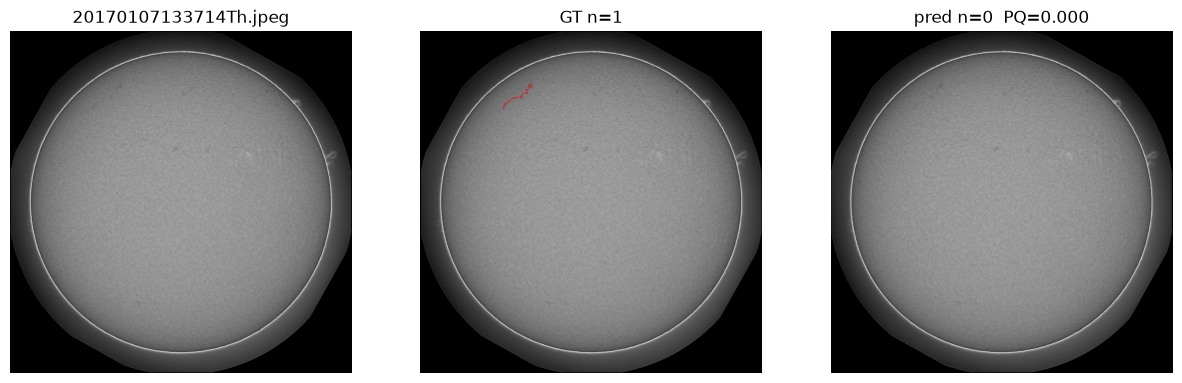

20170107133714Th.jpeg PQ 0.0 Dice 0.0 splits 0 merges 0


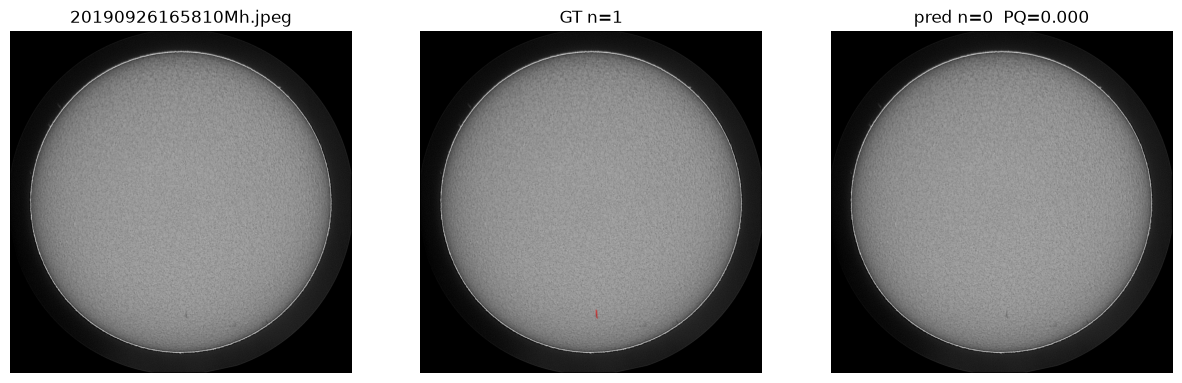

20190926165810Mh.jpeg PQ 0.0 Dice 0.0 splits 0 merges 0


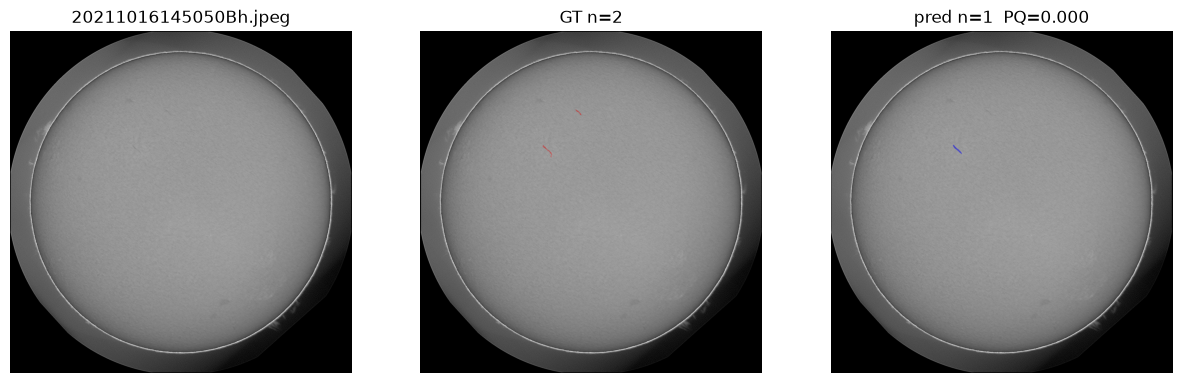

20211016145050Bh.jpeg PQ 0.0 Dice 0.521 splits 0 merges 0


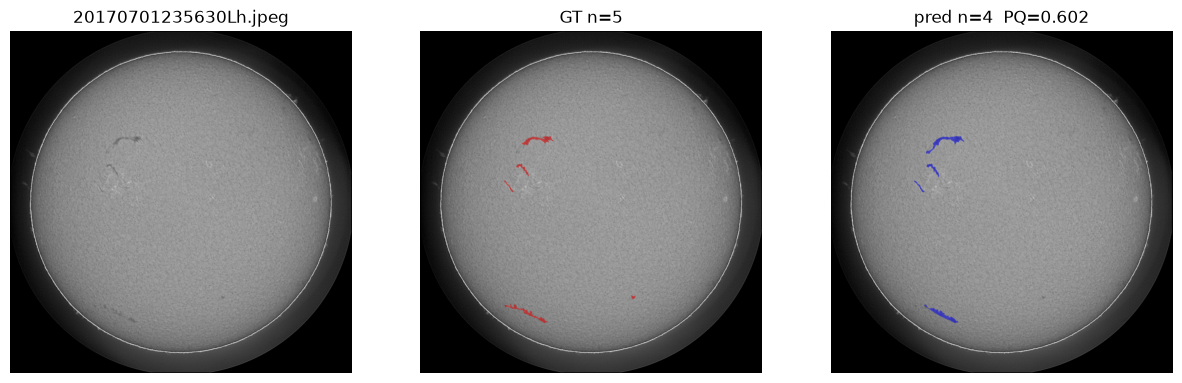

20170701235630Lh.jpeg PQ 0.602 Dice 0.764 splits 0 merges 0


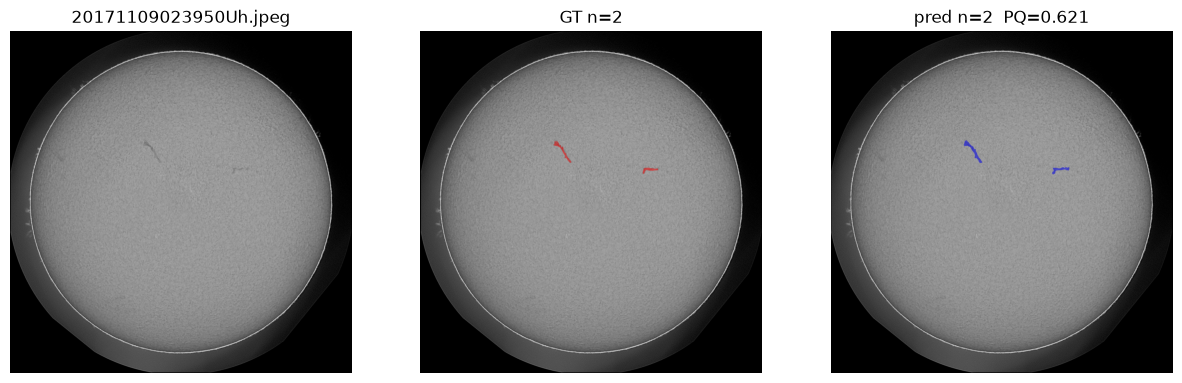

20171109023950Uh.jpeg PQ 0.621 Dice 0.774 splits 0 merges 0


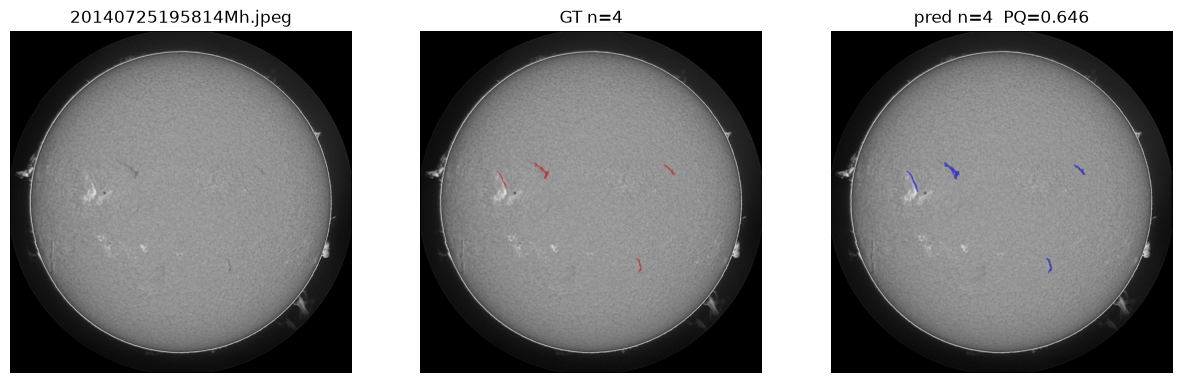

20140725195814Mh.jpeg PQ 0.646 Dice 0.782 splits 0 merges 0


In [47]:
import matplotlib.pyplot as plt

ranked = sorted(rows, key=lambda r: r["pq"])
show = ranked[:3] + ranked[-3:]

for r in show:
    fn = r["file"]
    gray = load_gray(IMAGE_FOLDER_PATH / fn)
    pred = instances_from_prob(
        predict_prob(fn, model),
        disk_mask(gray),
        t=0.45,
        min_area=500,
    )
    image_id = file_to_image_ids[fn][0]
    gt = instance_mask(anns_by_image_id[image_id])
    gt_u = np.any(gt, axis=0) if len(gt) else np.zeros_like(gray, dtype=bool)
    pr_u = np.any(pred, axis=0) if pred else np.zeros_like(gray, dtype=bool)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(gray, cmap="gray")
    ax[0].set_title(fn)
    ax[1].imshow(gray, cmap="gray")
    ax[1].imshow(np.ma.masked_where(~gt_u, gt_u), cmap="autumn", alpha=0.5)
    ax[1].set_title(f"GT n={r['n_gt']}")
    ax[2].imshow(gray, cmap="gray")
    ax[2].imshow(np.ma.masked_where(~pr_u, pr_u), cmap="winter", alpha=0.5)
    ax[2].set_title(f"pred n={r['n_pred']}  PQ={r['pq']:.3f}")
    for a in ax:
        a.axis("off")
    plt.show()
    print(fn, "PQ", round(r["pq"], 3), "Dice", round(r["sem_dice"], 3),
          "splits", r["one_to_many"], "merges", r["many_to_one"])

# Submission

In [ ]:
import pandas as pd
from pycocotools import mask as mask_utils
TEST_DIR = PROJECT_ROOT/"MAGFiLO_1.0_Kaggle_2026"/"test"/"test_images"
OUT = PROJECT_ROOT/"submission.csv"

def mask_to_rle_counts(m):
    rle = mask_utils.encode(np.asfortranarray(m.astype(np.uint8)))
    counts = rle['counts']
    return counts.decode('ascii') if isinstance(counts, bytes) else counts
paths = sorted(TEST_DIR.glob("*.jpeg"))
print("test", len(paths))

rows = []
for path in tqdm(paths, desc = "test"):
    inst = instances_from_prob(
        predict_prob(path.name, model, image_dir = TEST_DIR),
        disk_mask(load_gray(path)),
        t = 0.45,
        min_area = 500
    )
    stem = path.stem
    for k,m in enumerate(inst, start = 1):
        if not np.asarray(m).any():
            continue
        rows.append({
            "filament_id": f"{stem}_{k}",
            "segmentation_rle": mask_to_rle_counts(m)
        })
sub = pd.DataFrame(rows, columns = ['filament_id','segmentation_rle'])
sub.to_csv(OUT, index = False)
sub.head()

test 180


test:   0%|          | 0/180 [00:00<?, ?it/s]

C:\Users\Vibhanshu Botke\AppData\Local\Temp\ipykernel_12024\3191751422.py:38: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  bw = remove_small_objects(bw, min_size=min_area)


,filament_id,segmentation_rle
0,20110120105534Ch_1,l_Vi22c02cn12ZQNOfn12YQNNgn12XQN0gn11XQNOhn11V...
1,20110120105534Ch_2,UjTQ23lo12N1O1O0O2O00O10O1O010O10000O1O1M2O2J6...
2,20110130110334Ch_1,kW\m13lo12O2N4M0O010O0O3aPNFTo1f0L2N2O1O1O0O2O...
3,20110130110334Ch_2,j_Pe21go1:M3N5L1OO2OkPNAhn1?VQNCkn1=QQNFon1e01...
4,20110214175414Mh_1,]]d[21ko16K4M3GEiPN>Uo18N101O0oNYOiRNh0Um1ZOiR...


In [51]:
sub.iloc[0]['segmentation_rle']

'l_Vi22c02cn12ZQNOfn12YQNNgn12XQN0gn11XQNOhn11VQN2in1OUQN2jn10RQN2Po1?0O2OO01O101N1O001N2O1O00100O100O100O1O1O100O010O010O0100O10O02O001N100O100O1O1O2N1001N2N2M2O0O2O0O100O101O010O0100O1000000O0100O0100O1O10O010O001O00010O01O0001N1N2O100O1000010O0O2O00000O2O1NW^YP1'

(2048, 2048) uint8 0 1 1469


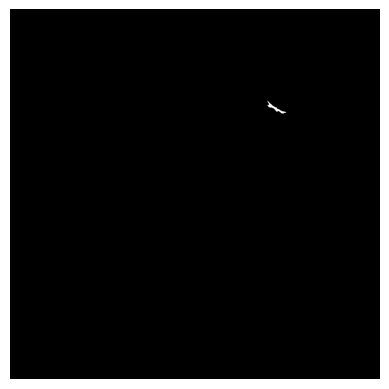

In [52]:
from pycocotools import mask as mask_utils
import numpy as np
import matplotlib.pyplot as plt

s = """l_Vi22c02cn12ZQNOfn12YQNNgn12XQN0gn11XQNOhn11VQN2in1OUQN2jn10RQN2Po1?0O2OO01O101N1O001N2O1O00100O100O100O1O1O100O010O010O0100O10O02O001N100O100O1O1O2N1001N2N2M2O0O2O0O100O101O010O0100O1000000O0100O0100O1O10O010O001O00010O01O0001N1N2O100O1000010O0O2O00000O2O1NW^YP1"""

rle = {"size": [2048, 2048], "counts": s.encode("ascii")}
m = mask_utils.decode(rle)
print(m.shape, m.dtype, m.min(), m.max(), m.sum())
plt.imshow(m, cmap="gray")
plt.axis("off")
plt.show()

In [53]:
sub.shape

(1330, 2)